In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_excel("Online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.rename(columns=str.lower, inplace=True)

In [6]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

In [7]:
print(type(df))

<class 'pandas.DataFrame'>


In [8]:
print(df.shape)

(541909, 8)


In [9]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

In [10]:
# See all countries where customers are located
print(df['country'].unique())

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str


In [11]:
# See unique statuses or invoice types
print(df['invoiceno'].unique()[:10]) # Looking at first 10 for brevity

[536365 536366 536367 536368 536369 536370 536371 536372 536373 536374]


## Preprocess Data

Calculate Recency

In [37]:
# convert date column to datetime format
df['date']= pd.to_datetime(df['invoicedate'])

In [38]:
# drop where customerid is null
df = df.dropna(subset=['customerid'])

In [39]:
# keep only the most recent date of purchase
df_rec = df.groupby('customerid')['date'].max().reset_index()

In [49]:
# total price
df['total_spend'] = df['quantity']*df['unitprice']

In [50]:
# calculate the ref data (latest date in the data)
latest_date = df_rec['date'].max()

# calculate days since that date
df_rec['recency'] = (latest_date - df_rec['date']).dt.days

In [51]:
df_rec.columns

Index(['customerid', 'date', 'recency'], dtype='str')

In [52]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'date', 'rank', 'total_spend'],
      dtype='str')

## RFM Analysis

In [84]:
# 1. THE AGGREGATION (Ensuring unique trips)

rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (latest_date - x.max()).days, # Recency
    'invoiceno': 'nunique',                               # Frequency (Unique trips!)
    'total_spend': 'sum'                                  # Monetary
}).rename(columns={'invoicedate': 'Recency', 'invoiceno': 'Frequency', 'total_spend': 'Monetary'})

In [87]:
# THE OUTLIER CHECK
# remove the top 5% of spenders to stop them from "clumping" the K-Means clusters

monetary_cutoff = rfm['Monetary'].quantile(0.95)
rfm = rfm[(rfm['Monetary'] > 0) & (rfm['Monetary'] <= monetary_cutoff)]

In [88]:
print(rfm.head())

            Recency  Frequency  Monetary
customerid                              
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40
12352.0          35         11   1545.41


## Cohort Analysis

In [89]:
# 1. Create a function to truncate dates to the first of the month
def get_month(x): return pd.Timestamp(x.year, x.month, 1)

# 2. Apply it to get the month of every transaction
df['invoicemonth'] = df['invoicedate'].apply(get_month)

# 3. Find the "Cohort Month" (the month of the very first purchase for each customer)
df['CohortMonth'] = df.groupby('customerid')['invoicemonth'].transform('min')

In [90]:
# 4. Calculate the "Cohort Index" (months since the first purchase)
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

In [91]:
invoice_year, invoice_month = get_date_int(df, 'invoicemonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

# +1 because the first month should be Month 1, not Month 0
df['CohortIndex'] = years_diff * 12 + months_diff + 1

In [92]:
# 1. Count unique customers per cohort per month
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['customerid'].nunique().reset_index()

# 2. Pivot the table
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='customerid')

# 3. Calculate percentages (Retention Rate)
cohort_sizes = cohort_pivot.iloc[:,0] # The first column is the total size of the cohort
retention = cohort_pivot.divide(cohort_sizes, axis=0)

# 4. Clean up the index for a prettier table
retention.index = retention.index.strftime('%Y-%m')

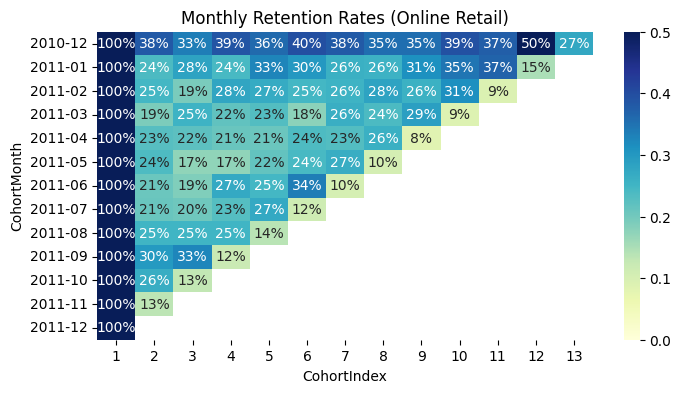

In [93]:
plt.figure(figsize=(8, 4))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=0.5)
plt.title('Monthly Retention Rates (Online Retail)')
plt.show()

#### Best Sellers and Revenue Distribution

In [94]:
# 1. Create a Revenue column if you haven't already
df['revenue'] = df['quantity'] * df['unitprice']

# 2. Group by StockCode and sum the Revenue
# We include Description so we know what the product actually is
top_products = df.groupby(['stockcode', 'description'])['revenue'].sum().reset_index()

# 3. Sort by Revenue in descending order and take the top 10
top_10_sellers = top_products.sort_values(by='revenue', ascending=False).head(10)

print(top_10_sellers)

     stockcode                         description    revenue
1249     22423            REGENCY CAKESTAND 3 TIER  132870.40
3593    85123A  WHITE HANGING HEART T-LIGHT HOLDER   93823.85
3586    85099B             JUMBO BAG RED RETROSPOT   83236.76
2613     47566                       PARTY BUNTING   67687.53
3915      POST                             POSTAGE   66710.24
2818     84879       ASSORTED COLOUR BIRD ORNAMENT   56499.22
1937     23084                  RABBIT NIGHT LIGHT   51137.80
2680     79321                       CHILLI LIGHTS   45936.81
932      22086     PAPER CHAIN KIT 50'S CHRISTMAS    41500.48
1324     22502      PICNIC BASKET WICKER 60 PIECES   39619.50


C:\Users\Hp\AppData\Local\Temp\ipykernel_15812\2947569686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sellers, x='revenue', y='description', palette='viridis')


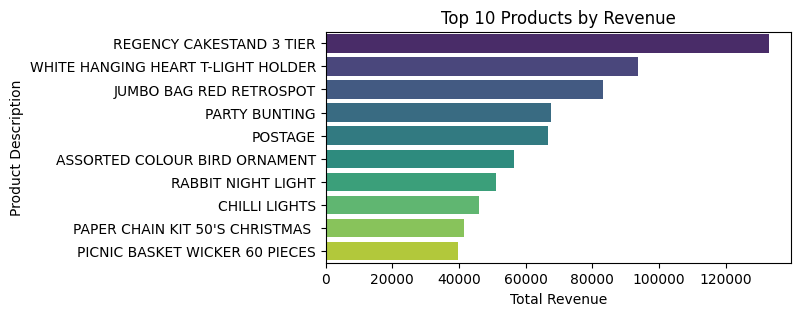

In [95]:
plt.figure(figsize=(6, 3))
sns.barplot(data=top_10_sellers, x='revenue', y='description', palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.show()

In [96]:
# Group by country and sum the revenue
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).reset_index()

# Calculate the percentage of total revenue
total_rev = country_revenue['revenue'].sum()
country_revenue['Percentage'] = (country_revenue['revenue'] / total_rev) * 100

# Display the top 10
print(country_revenue.head(10))

          country      revenue  Percentage
0  United Kingdom  6767873.394   81.539997
1     Netherlands   284661.540    3.429630
2            EIRE   250285.220    3.015461
3         Germany   221698.210    2.671042
4          France   196712.840    2.370015
5       Australia   137077.270    1.651520
6     Switzerland    55739.400    0.671554
7           Spain    54774.580    0.659929
8         Belgium    40910.960    0.492899
9          Sweden    36595.910    0.440911


C:\Users\Hp\AppData\Local\Temp\ipykernel_15812\1023722345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_revenue.head(15), x='revenue', y='country', palette='magma')


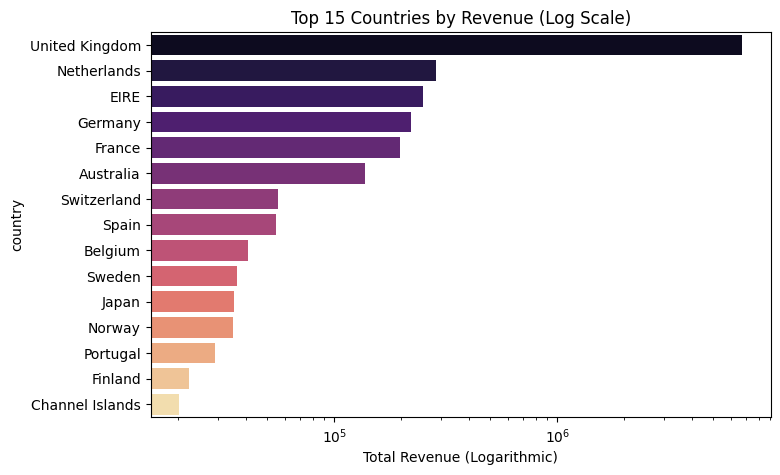

In [97]:
plt.figure(figsize=(8, 5))
sns.barplot(data=country_revenue.head(15), x='revenue', y='country', palette='magma')
plt.xscale('log') # Log scale makes smaller countries visible
plt.title('Top 15 Countries by Revenue (Log Scale)')
plt.xlabel('Total Revenue (Logarithmic)')
plt.show()

#### Log Transformation (for skewness)

In [100]:
# 1. Use log1p to handle 0 values 
rfm_log = np.log1p(rfm) 

# 2. Double check for any remaining non-finite values (NaN or Inf)
if not np.isfinite(rfm_log).all().all():
    print("Warning: Still found non-finite values. Dropping them...")
    rfm_log = rfm_log.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 4. Final DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_log.index, columns=rfm.columns)

print("Pre-processing successful!")

Pre-processing successful!


In [101]:
# Save the scaled data
rfm_scaled_df.to_csv('rfm_for_model.csv', index=True)

# Save the original RFM values (for interpreting clusters later)
rfm.to_csv('rfm_original_values.csv', index=True)